# Cargar el fichero con los datos limpios

In [1]:
import pandas as pd  # Para manejo de datos
import numpy as np   # Para operaciones numéricas
import matplotlib.pyplot as plt  # Para visualizaciones interactivas
import seaborn as sns # Para gráficos estadísticos

In [2]:
# Carga dataset principal
df_clean = pd.read_csv('./data_madrid/datClean.csv', sep=',')
# Aseguramos que sea DataFrame
df_clean = pd.DataFrame(df_clean)
# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [3]:
df_clean.head(3)

,PrecioActual,metros,habitaciones,ascensor,localizacion,plantaN,zona_id,tipo_inmueble_id
0,355000,69,2.0,1,1,5.0,8,5
1,149000,91,3.0,0,1,1.0,4,5
2,195000,36,1.0,1,1,2.0,5,5


# Comenzando con el entrenamiento del modelo
### sklearn.tree.DecisionTreeRegressor

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración para gráficos más bonitos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Para reproducibilidad - esto asegura que obtenemos los mismos resultados cada vez
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


# Probando a quitar precios muy elevados

In [5]:
# df_clean = df_clean[df_clean['PrecioActual'] <= 500000]
# cuantos = df_clean[df_clean['PrecioActual'] > 500000]['PrecioActual'].count()
# print(cuantos)

In [6]:
# df_clean.drop(['zona_id', 'tipo_inmueble_id'], axis=1, inplace=True)
# df_clean.head(3)

# train 80% - test 20%

In [7]:
# 1. Preparamos los datos
X = df_clean.drop(['PrecioActual'], axis=1)  # Características
y = df_clean['PrecioActual']  # Etiquetas
# 2. Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [8]:
X_train.head()

,metros,habitaciones,ascensor,localizacion,plantaN,zona_id,tipo_inmueble_id
7151,132,1.0,0,1,1.0,5,5
8250,450,5.0,0,1,1.0,17,5
7157,60,1.0,1,1,0.0,21,5
4826,108,3.0,1,1,1.0,21,5
10161,70,3.0,0,1,3.0,14,5


In [9]:
y_train.head()

7151     710000
8250     650000
7157     210000
4826     127000
10161    146000
Name: PrecioActual, dtype: int64

In [10]:
print(f"\nDespués de la división:")
print(f"  🎯 Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"  ✅ Prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")


Después de la división:
  🎯 Entrenamiento: 8923 muestras (80.0%)
  ✅ Prueba: 2231 muestras (20.0%)


In [11]:
# 3. Crear el modelo DecisionTreeRegressor
# Se usa max_depth para controlar el sobreajuste (overfitting)
regr_1 = DecisionTreeRegressor(max_depth=5)
regr_2 = DecisionTreeRegressor(max_depth=7)

# regr_1 = DecisionTreeRegressor(max_depth=5, min_samples_split=20, min_samples_leaf=10)
# regr_2 = DecisionTreeRegressor(max_depth=7, min_samples_split=20, min_samples_leaf=10)

In [12]:
# 4. Entrenar el modelo
regr_1.fit(X_train, y_train)
regr_2.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [13]:
# 5. Predecir
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

In [14]:
# 6. Evaluación de Métricas
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Métricas {nombre_modelo} ---")
    print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
    print(f"MAE (Error Absoluto Medio): {mae:.4f}")
    print(f"R2 (Coeficiente de Determinación): {r2:.4f}\n")

evaluar_modelo(y_test, y_1, "Árbol Profundidad 5")
evaluar_modelo(y_test, y_2, "Árbol Profundidad 7")

--- Métricas Árbol Profundidad 5 ---
MSE (Error Cuadrático Medio): 194051920796.4336
MAE (Error Absoluto Medio): 269738.6648
R2 (Coeficiente de Determinación): 0.7602

--- Métricas Árbol Profundidad 7 ---
MSE (Error Cuadrático Medio): 156299341058.5724
MAE (Error Absoluto Medio): 232610.3749
R2 (Coeficiente de Determinación): 0.8068



In [15]:
# Evaluamos
train_accuracy = regr_1.score(X_train, y_train)
test_accuracy = regr_1.score(X_test, y_test)

print(f"\n📊 Resultados profundidad 5:")
print(f"  Precisión en entrenamiento: {train_accuracy*100:.2f}%")
print(f"  Precisión en prueba: {test_accuracy*100:.2f}%")
print(f"  Diferencia: {abs(train_accuracy - test_accuracy)*100:.2f}%")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("\n✅ El modelo generaliza bien (diferencia < 5%)")
else:
    print("\n⚠️ Hay diferencia significativa entre train y test")


📊 Resultados profundidad 5:
  Precisión en entrenamiento: 80.02%
  Precisión en prueba: 76.02%
  Diferencia: 4.00%

✅ El modelo generaliza bien (diferencia < 5%)


In [16]:
# Evaluamos
train_accuracy = regr_2.score(X_train, y_train)
test_accuracy = regr_2.score(X_test, y_test)

print(f"\n📊 Resultados profundidad 7:")
print(f"  Precisión en entrenamiento: {train_accuracy*100:.2f}%")
print(f"  Precisión en prueba: {test_accuracy*100:.2f}%")
print(f"  Diferencia: {abs(train_accuracy - test_accuracy)*100:.2f}%")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("\n✅ El modelo generaliza bien (diferencia < 5%)")
else:
    print("\n⚠️ Hay diferencia significativa entre train y test")


📊 Resultados profundidad 7:
  Precisión en entrenamiento: 85.74%
  Precisión en prueba: 80.68%
  Diferencia: 5.06%

⚠️ Hay diferencia significativa entre train y test


In [17]:
X.shape

(11154, 7)

In [18]:
y.shape

(11154,)

In [19]:
df_clean.head()

,PrecioActual,metros,habitaciones,ascensor,localizacion,plantaN,zona_id,tipo_inmueble_id
0,355000,69,2.0,1,1,5.0,8,5
1,149000,91,3.0,0,1,1.0,4,5
2,195000,36,1.0,1,1,2.0,5,5
3,195000,58,1.0,1,0,0.0,18,5
4,715000,140,3.0,1,1,2.0,17,3


### Visualizar el arbol creado

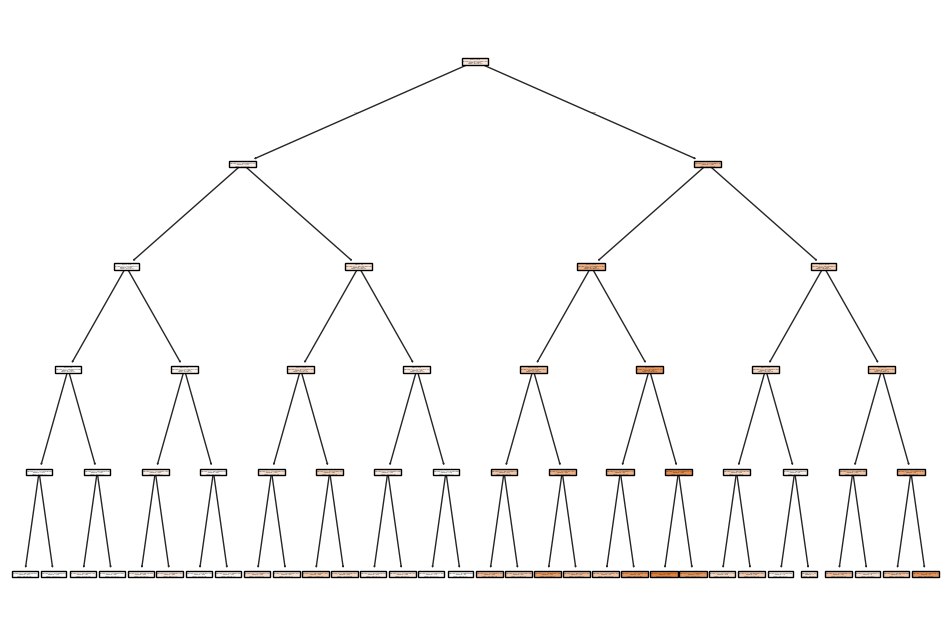

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(regr_1, filled=True)
plt.show()

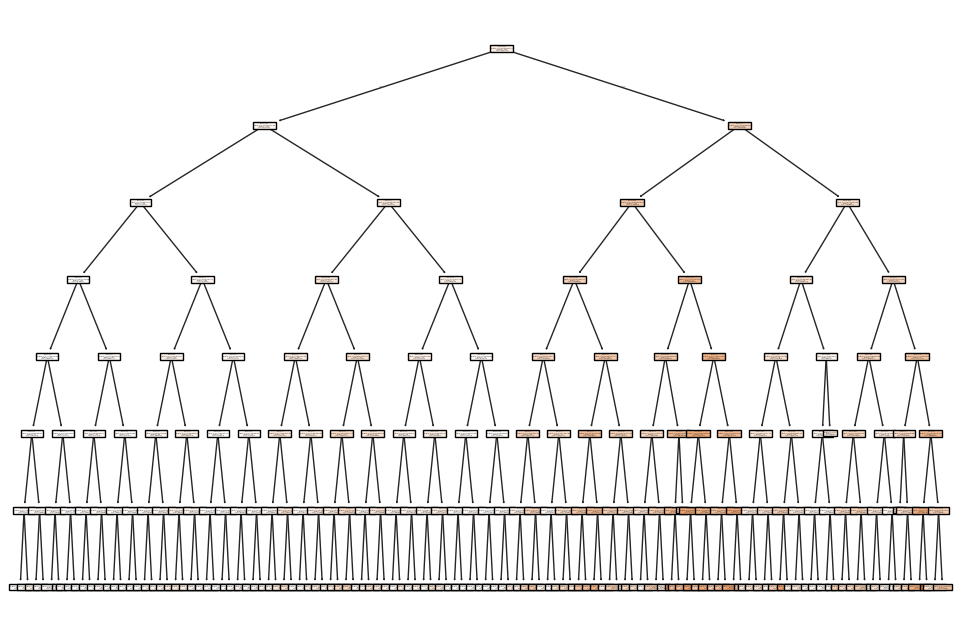

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(regr_2, filled=True)
plt.show()

### xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

# Probando modelo sencillo linear regresion

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
# 1. Preparamos los datos
X = df_clean.drop(['PrecioActual'], axis=1)  # Características
y = df_clean['PrecioActual']  # Etiquetas

# 2. Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# 3. Crear el modelo DecisionTreeRegressor
model = LinearRegression()

# 4. Entrenar el modelo
model.fit(X_train, y_train)

# 5. Hacer predicciones
y_pred = model.predict(X_test)

# 6. Ver las métricas de evaluación
print("--- Métricas de Regresión Lineal ---")
# Coeficiente de determinación (R^2): Mejor valor es 1.0
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")

# Error Cuadrático Medio (MSE): Mide el promedio de los errores al cuadrado
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")

# Raíz del Error Cuadrático Medio (RMSE): Más interpretable que MSE
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Error Absoluto Medio (MAE): Promedio de los errores absolutos
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")

# 6. Parámetros del modelo (pendiente e intercepto)
print(f"\nCoeficiente (Pendiente - m): {model.coef_[0]:.4f}")
print(f"Intercepto (b): {model.intercept_:.4f}")

--- Métricas de Regresión Lineal ---
R-squared: 0.7143
Mean Squared Error (MSE): 231206527611.5411
Root Mean Squared Error (RMSE): 480839.3990
Mean Absolute Error (MAE): 320754.5685

Coeficiente (Pendiente - m): 8763.3846
Intercepto (b): -639849.3363


### xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

# Segunda prueba

# train 70% - validacion 15% - test 15%

In [24]:
print("="*60)
print("EJEMPLO 2: División Completa con Validación (70-15-15)")
print("="*60)

# Primera división: separamos los datos de prueba
# Esto es importante: primero separamos test y NO lo volvemos a tocar
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,  # 15% para prueba
    random_state=42
)

print(f"\nPrimera división (separar test):")
print(f"  Datos temporales: {X_temp.shape[0]} muestras (85%)")
print(f"  Datos de prueba: {X_test.shape[0]} muestras (15%)")
print(f"  ⚠️ Los datos de prueba quedan guardados y NO se tocan hasta el final")

# Segunda división: del resto, separamos train y validación
# Queremos aproximadamente 70% del total para train y 15% para validación
# Como ya tenemos 85%, hacemos: 70/85 ≈ 0.82 para train
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 15/85 ≈ 0.176 para obtener 15% del total
    random_state=42
)

print(f"\nSegunda división (separar validación):")
print(f"  🎯 Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"  🔍 Validación: {X_val.shape[0]} muestras ({X_val.shape[0]/X.shape[0]*100:.1f}%)")
print(f"  ✅ Prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

EJEMPLO 2: División Completa con Validación (70-15-15)

Primera división (separar test):
  Datos temporales: 9480 muestras (85%)
  Datos de prueba: 1674 muestras (15%)
  ⚠️ Los datos de prueba quedan guardados y NO se tocan hasta el final

Segunda división (separar validación):
  🎯 Entrenamiento: 7811 muestras (70.0%)
  🔍 Validación: 1669 muestras (15.0%)
  ✅ Prueba: 1674 muestras (15.0%)


In [25]:
# Ahora vamos a probar diferentes configuraciones usando validación
print("\n" + "="*60)
print("PROBANDO DIFERENTES MODELOS CON VALIDACIÓN")
print("="*60)

# Probamos diferentes profundidades de árbol de decisión
profundidades = [1, 3, 5, 7, 9, 10]
resultados_val = []

for depth in profundidades:
    # Entrenamos el modelo
    modelo = DecisionTreeRegressor(max_depth=depth, random_state=42)
    modelo.fit(X_train, y_train)
    
    # Evaluamos en entrenamiento y validación
    train_acc = modelo.score(X_train, y_train)
    val_acc = modelo.score(X_val, y_val)
    
    resultados_val.append({
        'profundidad': depth,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'diferencia': train_acc - val_acc
    })
    
    print(f"\nProfundidad {depth:2d}: Train={train_acc:.3f}, Val={val_acc:.3f}, Diff={train_acc-val_acc:.3f}")

# Convertimos a DataFrame para análisis
df_resultados = pd.DataFrame(resultados_val)

# Encontramos el mejor modelo según validación
mejor_idx = df_resultados['val_accuracy'].idxmax()
mejor_depth = df_resultados.loc[mejor_idx, 'profundidad']

print(f"\n{'='*60}")
print(f"🏆 MEJOR MODELO: Profundidad = {mejor_depth}")
print(f"{'='*60}")

# Ahora entrenamos el mejor modelo en train+validación
# (Esto es opcional pero recomendado para usar todos los datos disponibles)
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

modelo_final = DecisionTreeRegressor(max_depth=int(mejor_depth), random_state=42)
modelo_final.fit(X_train_full, y_train_full)

# AHORA SÍ, evaluamos en test (solo una vez)
test_accuracy = modelo_final.score(X_test, y_test)

print(f"\n✅ EVALUACIÓN FINAL EN TEST:")
print(f"  Precisión en prueba: {test_accuracy*100:.2f}%")
print(f"\n💡 Este es el número que reportaríamos como el rendimiento real del modelo.")


PROBANDO DIFERENTES MODELOS CON VALIDACIÓN

Profundidad  1: Train=0.498, Val=0.477, Diff=0.021

Profundidad  3: Train=0.721, Val=0.681, Diff=0.040

Profundidad  5: Train=0.792, Val=0.745, Diff=0.047

Profundidad  7: Train=0.862, Val=0.805, Diff=0.058

Profundidad  9: Train=0.904, Val=0.817, Diff=0.087

Profundidad 10: Train=0.921, Val=0.799, Diff=0.122

🏆 MEJOR MODELO: Profundidad = 9

✅ EVALUACIÓN FINAL EN TEST:
  Precisión en prueba: 83.27%

💡 Este es el número que reportaríamos como el rendimiento real del modelo.


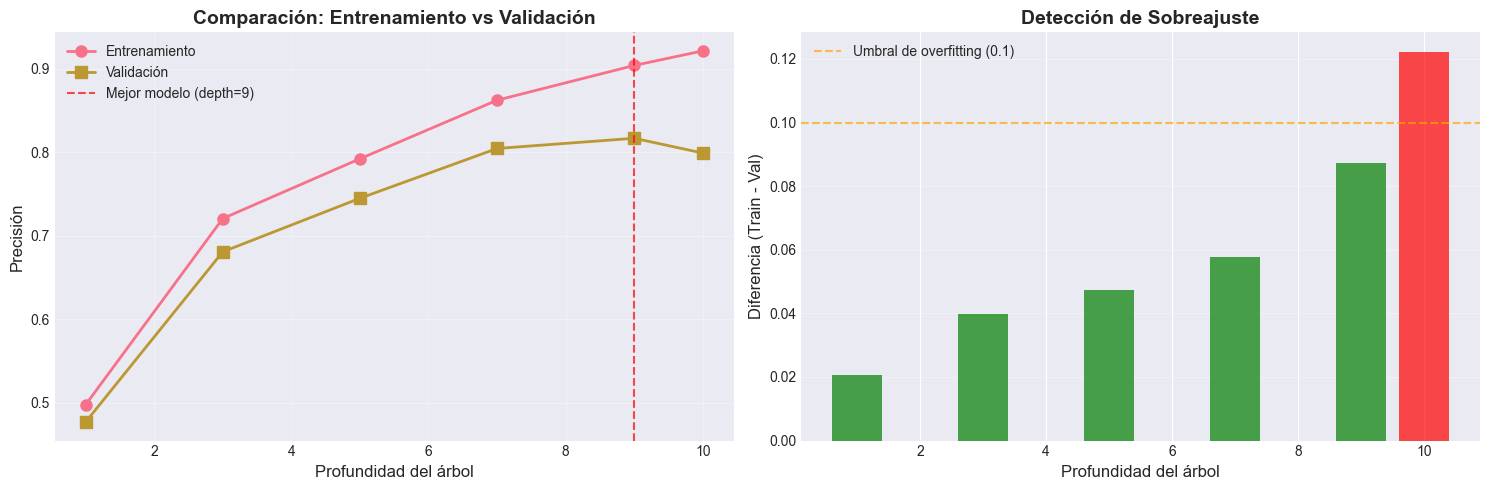


📊 Interpretación:
  - Verde: Buen balance, el modelo generaliza bien
  - Rojo: Posible overfitting, el modelo memoriza los datos de entrenamiento


In [26]:
# Visualización de los resultados de validación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Precisión vs Profundidad
ax1.plot(df_resultados['profundidad'], df_resultados['train_accuracy'], 
         marker='o', label='Entrenamiento', linewidth=2, markersize=8)
ax1.plot(df_resultados['profundidad'], df_resultados['val_accuracy'], 
         marker='s', label='Validación', linewidth=2, markersize=8)
ax1.axvline(x=mejor_depth, color='red', linestyle='--', alpha=0.7, 
            label=f'Mejor modelo (depth={mejor_depth})')
ax1.set_xlabel('Profundidad del árbol', fontsize=12)
ax1.set_ylabel('Precisión', fontsize=12)
ax1.set_title('Comparación: Entrenamiento vs Validación', fontsize=14, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Diferencia (señal de overfitting)
ax2.bar(df_resultados['profundidad'], df_resultados['diferencia'], 
        color=['red' if d > 0.1 else 'green' for d in df_resultados['diferencia']], alpha=0.7)
ax2.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, 
            label='Umbral de overfitting (0.1)')
ax2.set_xlabel('Profundidad del árbol', fontsize=12)
ax2.set_ylabel('Diferencia (Train - Val)', fontsize=12)
ax2.set_title('Detección de Sobreajuste', fontsize=14, weight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("  - Verde: Buen balance, el modelo generaliza bien")
print("  - Rojo: Posible overfitting, el modelo memoriza los datos de entrenamiento")

# Guardar el modelo para usarlo cuando quiera

In [27]:
import joblib

# Supongamos que 'modelo' es tu modelo ya entrenado (ej. RandomForest, SVM)
# Guardar el modelo en un archivo .pkl o .joblib
joblib.dump(modelo_final, 'mi_modelo_entrenado.joblib')
print("Modelo guardado exitosamente.")


Modelo guardado exitosamente.


# Ultima prueba con Cross_Validation

In [28]:
from sklearn.model_selection import cross_val_score, KFold

print("="*60)
print("VALIDACIÓN CRUZADA (K-Fold)")
print("="*60)

# 1. Preparamos los datos
X = df_clean.drop(['PrecioActual'], axis=1)  # Características
y = df_clean['PrecioActual']  # Etiquetas

# Primero separamos test (que NO usaremos en cross-validation)
X_temp, X_test_cv, y_temp, y_test_cv = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nDatos para cross-validation: {len(X_temp)} muestras")
print(f"Datos de prueba (guardados): {len(X_test_cv)} muestras")

# Configuramos K-Fold con 5 pliegues
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Definir los modelos
model_depth_5 = DecisionTreeRegressor(max_depth=5, random_state=42)
model_depth_7 = DecisionTreeRegressor(max_depth=7, random_state=42)
model_depth_9 = DecisionTreeRegressor(max_depth=9, random_state=42)

# 4. Realizar la validación cruzada
# Usamos 'neg_mean_squared_error' porque cross_val_score busca maximizar, 
# y queremos minimizar el MSE.
scores_5 = cross_val_score(model_depth_5, X, y, cv=kfold, scoring='neg_mean_squared_error')
scores_7 = cross_val_score(model_depth_7, X, y, cv=kfold, scoring='neg_mean_squared_error')
scores_9 = cross_val_score(model_depth_9, X, y, cv=kfold, scoring='neg_mean_squared_error')

# 5. Calcular promedios (convertir de vuelta a positivos)
mean_mse_5 = -scores_5.mean()
mean_mse_7 = -scores_7.mean()
mean_mse_9 = -scores_9.mean()

print(f"MSE Promedio (Depth 5): {mean_mse_5:.4f}")
print(f"MSE Promedio (Depth 7): {mean_mse_7:.4f}")
print(f"MSE Promedio (Depth 9): {mean_mse_9:.4f}")

# 6. Comparación
# if mean_mse_5 < mean_mse_7:
#     print("El modelo de profundidad 5 es mejor.")
# else:
#     print("El modelo de profundidad 7 es mejor.")

VALIDACIÓN CRUZADA (K-Fold)

Datos para cross-validation: 8923 muestras
Datos de prueba (guardados): 2231 muestras
MSE Promedio (Depth 5): 183066152209.5348
MSE Promedio (Depth 7): 143899604050.6327
MSE Promedio (Depth 9): 145634445434.4328
